# Read images and visualize

In [4]:
import glob
import os

base = os.path.expanduser("/Users/timzhou/Desktop")  # your home directory
exp = glob.glob(os.path.join(base, "GB_exp", "*.xyz"))
sim = glob.glob(os.path.join(base, "GB_sim", "*.xyz"))

print(exp)
print(sim)

['/Users/timzhou/Desktop/GB_exp/grapheneGBexperiment_tM=09.439deg_tL=03.409deg_0633.xyz', '/Users/timzhou/Desktop/GB_exp/grapheneGBexperiment_tM=12.890deg_tL=04.121deg_0935.xyz', '/Users/timzhou/Desktop/GB_exp/grapheneGBexperiment_tM=37.741deg_tL=04.711deg_0622.xyz', '/Users/timzhou/Desktop/GB_exp/grapheneGBexperiment_tM=21.339deg_tL=05.018deg_0362.xyz', '/Users/timzhou/Desktop/GB_exp/grapheneGBexperiment_tM=29.825deg_tL=04.216deg_1028.xyz', '/Users/timzhou/Desktop/GB_exp/grapheneGBexperiment_tM=47.156deg_tL=13.462deg_0913.xyz']
['/Users/timzhou/Desktop/GB_sim/30_4.xyz', '/Users/timzhou/Desktop/GB_sim/47_13.xyz', '/Users/timzhou/Desktop/GB_sim/13_4.xyz', '/Users/timzhou/Desktop/GB_sim/37.5_4.5.xyz', '/Users/timzhou/Desktop/GB_sim/9.5_3.5.xyz', '/Users/timzhou/Desktop/GB_sim/21_5.xyz']


Misorientation sim: 47.0
Line sim: 13.0
Misorientation exp: 47.156
Line exp: 13.462
Atoms sim: (24446, 3)
Atoms exp: (793, 3)


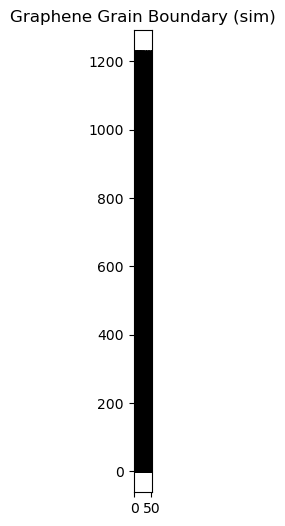

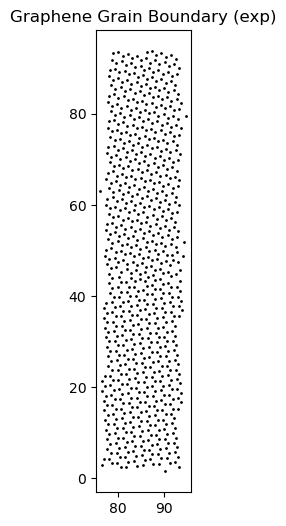

In [33]:
import numpy as np
import re
import matplotlib.pyplot as plt

def read_gb_xyz(filename):

    with open(filename) as f:
        lines = f.readlines()

    # header
    misorientation, line_angle = map(float, lines[0].split())
    box = list(map(float, lines[1].split()))

    coords = []

    for line in lines[2:]:
        if line.strip() == "":
            continue

        parts = line.split()
        x, y, z = map(float, parts[:3])   # only first 3 columns
        coords.append([x, y, z])

    coords = np.array(coords)

    return misorientation, line_angle, box, coords

mis, angle, box, atoms = read_gb_xyz(sim[1])

def read_exp_gb_xyz(filename):

    # 1. Parse angles from filename

    m = re.search(r'tM=([\d.]+)deg_tL=([\d.]+)deg', filename)

    misorientation = float(m.group(1))
    line_angle = float(m.group(2))

    # 2. Read coordinates

    coords = []

    with open(filename) as f:
        lines = f.readlines()

    for line in lines:

        parts = line.split()

        # coordinate lines have exactly 3 numbers
        if len(parts) == 3:

            try:
                x, y, z = map(float, parts)
                coords.append([x, y, z])
            except:
                pass

    coords = np.array(coords)

    return misorientation, line_angle, coords

mis1, angle1, atoms1 = read_exp_gb_xyz(exp[5])

print("Misorientation sim:", mis)
print("Line sim:", angle)

print("Misorientation exp:", mis1)
print("Line exp:", angle1)

print("Atoms sim:", atoms.shape)
print("Atoms exp:", atoms1.shape)

plt.figure(figsize=(6,6))
plt.scatter(atoms[:,0], atoms[:,1], s=1, c='k')
plt.gca().set_aspect('equal', adjustable='box')  # keep square pixels
plt.title("Graphene Grain Boundary (sim)")
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(atoms1[:,0], atoms1[:,1], s=1, c='k')
plt.gca().set_aspect('equal', adjustable='box')  # keep square pixels
plt.title("Graphene Grain Boundary (exp)")
plt.show()

# Generate Band Contrast Maps

/var/folders/2l/503mmdd576vfgvmvb3nl0_cw0000gn/T/ipykernel_5239/2758023371.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


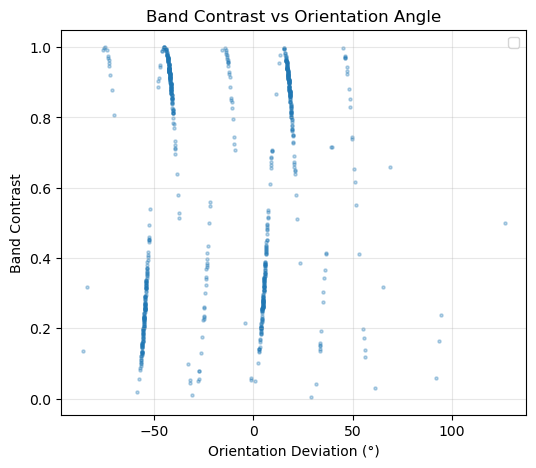

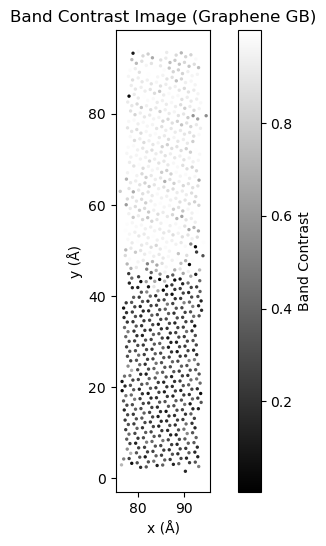

In [38]:
from scipy.spatial import KDTree
import numpy as np

def band_contrast_map(thickness=3.35,
                      orientation_angles=None,
                      xi_g=50.0,
                      bragg_s_range=0.05):

    orientation_angles = np.asarray(orientation_angles)

    # Convert orientation → excitation error
    s_g_values = orientation_angles / 5.0 * bragg_s_range

    xi_eff = xi_g / np.sqrt(1 + (s_g_values * xi_g)**2)

    I_g = np.sin(np.pi * thickness / xi_eff)**2

    contrast = np.abs(I_g - 0.5)

    return s_g_values, contrast

def local_orientations(coords, k=3):

    tree = KDTree(coords[:, :2])
    orientations = np.zeros(len(coords))

    for i, p in enumerate(coords):

        d, idx = tree.query(p[:2], k=k+1)

        neighbors = coords[idx[1:], :2] - p[:2]

        angles = np.arctan2(neighbors[:,1], neighbors[:,0])

        orientations[i] = np.mean(angles)

    return np.degrees(orientations)

ori_sim = local_orientations(atoms)
ori_exp = local_orientations(atoms1)

sg_sim, contrast_sim = band_contrast_map(
                        orientation_angles=ori_sim)

sg_exp, contrast_exp = band_contrast_map(
                        orientation_angles=ori_exp)

thickness = 3.35  # Å (single-layer graphene)
bragg_s_range = 0.05
xi_g = 50.0

orientations = ori_exp # Toggle experimental/simulated orientation

contrast_map = np.zeros(len(orientations))

for i, ori in enumerate(orientations):

    s_g = ori / 5.0 * bragg_s_range
    xi_eff = xi_g / np.sqrt(1 + (s_g * xi_g)**2)

    I_g = np.sin(np.pi * thickness / xi_eff)**2

    contrast_map[i] = I_g

plt.figure(figsize=(6,5))

plt.scatter(orientations, contrast_map,
            s=5, alpha=0.3)

plt.xlabel("Orientation Deviation (°)")
plt.ylabel("Band Contrast")
plt.title("Band Contrast vs Orientation Angle")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7,6))

plt.scatter(atoms1[:,0], atoms1[:,1],
            c=contrast_map,
            cmap='gray',
            s=2) # Toggle atom/atom1 to show simulated/experimental data 

plt.gca().set_aspect('equal')

plt.xlabel("x (Å)")
plt.ylabel("y (Å)")
plt.title("Band Contrast Image (Graphene GB)")

# plt.ylim(0,50)  # limit y-axis for experimental long strips

plt.colorbar(label="Band Contrast")

plt.show()

# Read Shockley/Average GB Energy Comparison

In [12]:
import numpy as np
from scipy.spatial import cKDTree

def local_strain_tensor(atoms, neighbor_cut=2.0):
    """
    Compute 2D strain tensor for each atom based on neighbor displacements.

    Parameters
    ----------
    atoms : np.ndarray, shape (N,2) x,y coordinates
    neighbor_cut : float
        Cutoff for neighbors (Å)

    Returns
    -------
    strain_tensors : np.ndarray, shape (N,2,2)
        Local 2x2 strain tensor for each atom
    """

    N = atoms.shape[0]
    strain_tensors = np.zeros((N,2,2))

    tree = cKDTree(atoms)

    for i in range(N):
        pos_i = atoms[i,:2]
        idx = tree.query_ball_point(pos_i, neighbor_cut)
        if len(idx) < 2:
            continue  # skip isolated atoms

        neighbors = atoms[idx,:2] - pos_i  # relative positions
        # linearized strain approximation
        u = neighbors - neighbors.mean(axis=0)

        # compute strain tensor: epsilon = 1/2 * (grad u + grad u^T)
        # approximate gradient using least squares: du/dx ~ inv(X^T X) X^T u
        X = np.hstack([neighbors, np.ones((len(neighbors),1))])
        try:
            # solve for linear mapping u = F x + c
            F, _, _, _ = np.linalg.lstsq(X, u, rcond=None)
            F = F[:2,:].T  # 2x2 deformation gradient
            epsilon = 0.5 * (F + F.T)
            strain_tensors[i,:,:] = epsilon
        except np.linalg.LinAlgError:
            continue

    return strain_tensors

def strain_energy_from_tensor(strain_tensors, k=45, d0=1.42):
    """
    Compute local strain energy from 2x2 strain tensor.
    """
    gamma = np.zeros(strain_tensors.shape[0])
    for i, eps in enumerate(strain_tensors):
        gamma[i] = 0.5 * k * np.trace(eps @ eps) * d0**2
    return gamma

atoms_xy = atoms[:, :2]   # simulated
atoms1_xy = atoms1[:, :2] # experimental

strain_sim = local_strain_tensor(atoms_xy)
strain_exp = local_strain_tensor(atoms1_xy)

gamma_sim = strain_energy_from_tensor(strain_sim)
gamma_exp = strain_energy_from_tensor(strain_exp)

print("Simulated GB energy avg:", np.mean(gamma_sim))
print("Experimental GB energy avg:", np.mean(gamma_exp))

Simulated GB energy avg: 90.62164081582806
Experimental GB energy avg: 90.47143713278496


# Complete plot

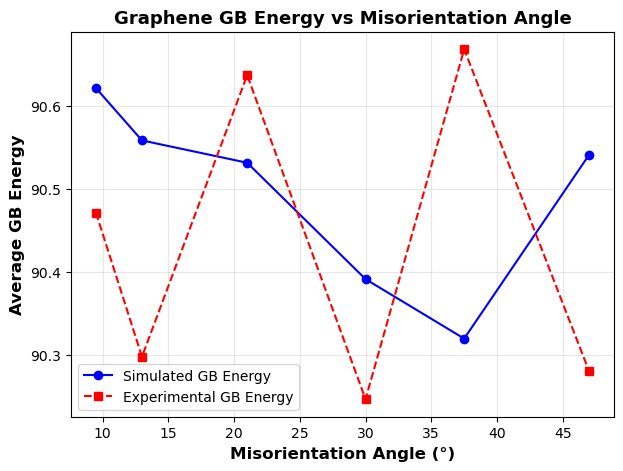

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Misorientation angles (from filename) in degrees
misorientation = np.array([9.5, 13, 21, 30, 37.5, 47])

# Average GB energies (from your calculations)
simulated_energy = np.array([90.62164081582806,
                             90.55854923011725,
                             90.53163254750085,
                             90.39137946963977,
                             90.31969242786252,
                             90.54127603697947])

experimental_energy = np.array([90.47143713278496,
                                90.29785298507463,
                                90.63718,
                                90.24663898916967,
                                90.66846896551723,
                                90.2803051702396])

plt.figure(figsize=(7,5))

# Plot simulated energies
plt.plot(misorientation, simulated_energy, 'o-', color='blue', label='Simulated GB Energy')

# Plot experimental energies
plt.plot(misorientation, experimental_energy, 's--', color='red', label='Experimental GB Energy')

plt.xlabel("Misorientation Angle (°)", fontsize=12, weight='bold')
plt.ylabel("Average GB Energy", fontsize=12, weight='bold')
plt.title("Graphene GB Energy vs Misorientation Angle", fontsize=13, weight='bold')
plt.grid(alpha=0.3)
plt.legend()
plt.show()